In [1]:
import os
import argparse
from types import SimpleNamespace
from pathlib import Path

import cortex

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import io, warnings
from contextlib import contextmanager, redirect_stdout, redirect_stderr
@contextmanager
def suppress_print():
    """Silence stdout/stderr and warnings inside the with-block."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        f, e = io.StringIO(), io.StringIO()
        with redirect_stdout(f), redirect_stderr(e):
            yield

import shutil, os, subprocess as sp
import re

def robust_inkscape_version():
    env = os.environ.copy()
    env.setdefault('LANG','C.UTF-8'); env.setdefault('LC_ALL','C.UTF-8')
    p = sp.run(['inkscape','--version'], stdout=sp.PIPE, stderr=sp.STDOUT, text=True, env=env)
    m = re.search(r'Inkscape\s+([0-9]+(?:\.[0-9]+)*)', p.stdout or "")
    return m.group(1) if m else '0'   # fallback minimal

import cortex, cortex.svgoverlay as svo
svo.INKSCAPE_VERSION = robust_inkscape_version()
print("Patched INKSCAPE_VERSION =", svo.INKSCAPE_VERSION)

os.chdir("/engram/nklab/pf2477/brain_decoding/")
from brain_adapter.dataset import nsd_topk_parcel_dataset, get_dominant_roi_per_parcel

Patched INKSCAPE_VERSION = 1.3


In [2]:
subj=1
args = SimpleNamespace(
        subj=subj,
        backbone_arch="dinov2_q",
        data_dir="/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data",
        imgs_dir="/engram/nklab/datasets/natural_scene_dataset/nsddata_stimuli/stimuli/nsd",
        parcel_dir="/engram/nklab/algonauts/ethan/whole_brain_encoder/parcels/schaefer",
        hemi=None,
)
args.tokenizer = None
args.gen_size = 512
args.topk = 100
print("Setting up test configuration for subject ", subj)

dataset = nsd_topk_parcel_dataset(args, split='test', transform=None, topk=args.topk)
print(len(dataset), "samples in the dataset")
# print(dataset.selected_parcel_idx)
print(len(dataset.selected_parcel_idx['lh']), "left hemisphere parcels")
print(len(dataset.selected_parcel_idx['rh']), "right hemisphere parcels")

Setting up test configuration for subject  1
Testing on subject: 1
515 samples in the dataset
100 left hemisphere parcels
100 right hemisphere parcels


In [3]:
neural_data_path = Path("/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data")
metadata = np.load(neural_data_path / f"metadata_sub-{subj:02}.npy", allow_pickle=True).item()

all_roi_names = list(metadata['lh_rois'].keys())[:24] + list(metadata['rh_rois'].keys())[:24]
print(f' all_roi_names: {all_roi_names}, len: {len(all_roi_names)}')

min_overlap_threshold = 0.5
dominant_rois = get_dominant_roi_per_parcel(dataset, metadata, all_roi_names, min_overlap_threshold=min_overlap_threshold)

print("\n" + "="*50)
print(f"DOMINANT ROI PER PARCEL (>{min_overlap_threshold*100}% overlap)")
print("="*50)

matched_rois = set()
for hemi in ['lh', 'rh']:
    print(f"\n{hemi.upper()} Hemisphere:")
    cnt = 0
    for parcel_idx, roi_name, overlap, num_voxels in dominant_rois[hemi]:
        # parcel_idx is the original parcel id in 500 parcels
        # if roi_name:
        #     print(f"Parcel idx {parcel_idx:3d}: {roi_name:20s} ({overlap:.1%}) in {num_voxels} Schaefer voxels")
        #     cnt += 1
        #     matched_rois.add(roi_name)
        # else:
        #     print(f"Parcel {parcel_idx:3d}: No ROI has >= {min_overlap_threshold:.1%} overlap")
        if hemi == 'lh' and (parcel_idx+1) in [211, 238, 496, 167, 367, 239, 217, 235, 217] and roi_name:
            print(f"Parcel idx {parcel_idx:3d}: {roi_name:20s} ({overlap:.1%}) in {num_voxels} Schaefer voxels")
        if hemi == 'rh' and (parcel_idx+1) in [373, 456, 476, 391] and roi_name:
            print(f"Parcel idx {parcel_idx:3d}: {roi_name:20s} ({overlap:.1%}) in {num_voxels} Schaefer voxels")

    print(f"Total parcels with dominant ROI in {hemi.upper()}: {cnt}")

print(matched_rois)


 all_roi_names: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words', 'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words'], len: 48
Processing 100 LH parcels with matrix operations...


LH: 100%|██████████| 100/100 [00:00<00:00, 266.35it/s]


Processing 100 RH parcels with matrix operations...


RH: 100%|██████████| 100/100 [00:00<00:00, 276.47it/s]


DOMINANT ROI PER PARCEL (>50.0% overlap)

LH Hemisphere:
Total parcels with dominant ROI in LH: 0

RH Hemisphere:
Total parcels with dominant ROI in RH: 0
set()


In [4]:

roi_groups = {
        # Early / retinotopic visual
        "V1": ["V1v", "V1d"],
        "V2": ["V2v", "V2d"],
        "V3": ["V3v", "V3d"],
        "V4": ["hV4"],

        # Higher-level ventral stream
        "Face": ["OFA", "FFA-1", "FFA-2"],
        "Body": ["EBA", "FBA-1", "FBA-2"],
        "Scene": ["PPA", "OPA", "RSC"],
        "Word": ["VWFA-1", "VWFA-2", "OWFA", "mfs-words"],
    }

def get_parcel_roi_mapping(parcel_id, hemi,dataset, roi_groups, dominant_rois):
    """
    Get the ROI name for a specific parcel ID.
    
    Args:
        parcel_id: ID of the parcel
        dataset: Dataset with parcel information
        roi_groups: Dictionary mapping ROI group names to ROI lists
        dominant_rois: Output from get_dominant_roi_per_parcel
        
    Returns:
        ROI name associated with the parcel, or None if not found
    """
    selected_parcel = dataset.selected_parcel_idx[hemi][parcel_id]
    parcel_roi_name = None
    for parcel_idx, roi_name, overlap, num_voxels in dominant_rois[hemi]:
        if parcel_idx == selected_parcel:
            parcel_roi_name = roi_name
            break
    
    return parcel_roi_name, selected_parcel

Selected parcel ID 35 corresponds to ROI: EBA - Body - rh


100%|██████████| 6/6 [00:10<00:00,  1.74s/it]



--------------------------------------------------------------------------------


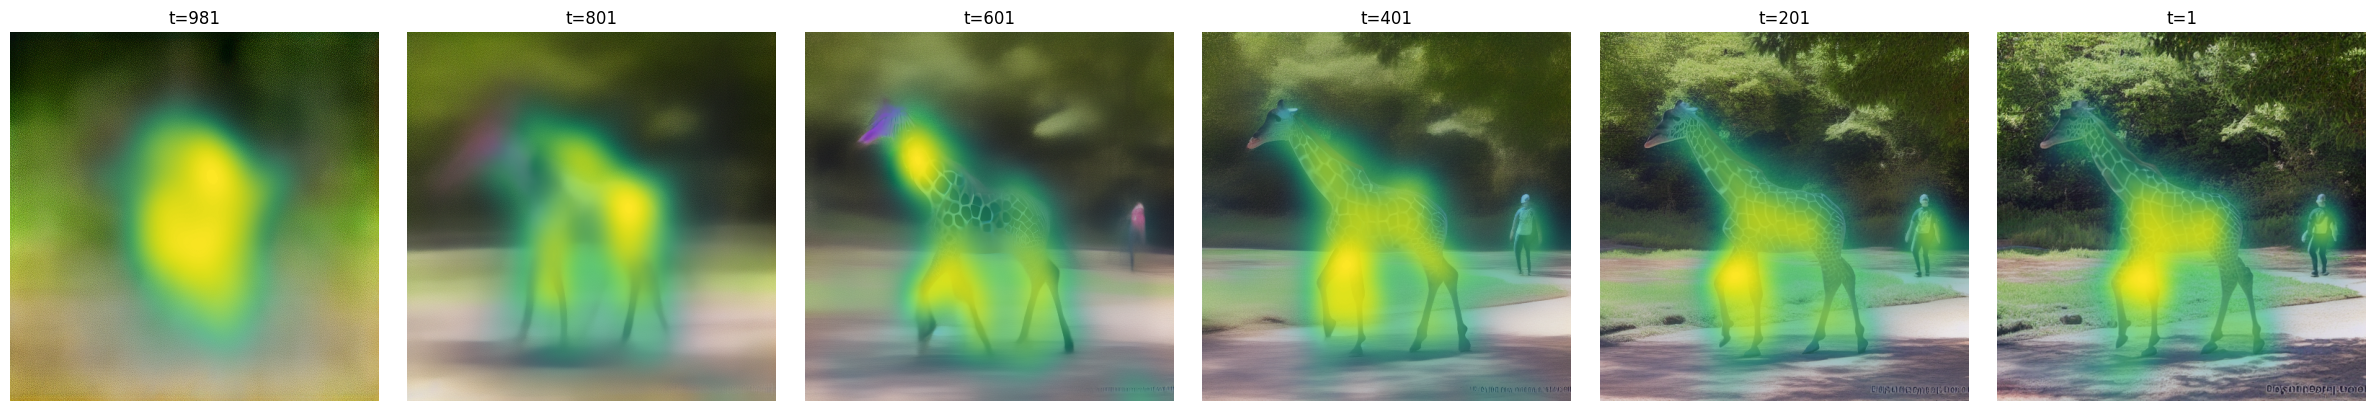

In [12]:

def compute_ROI_attention_map(attn_maps, R, image_shape):
    """
    Compute ROI attention map following the specified pseudocode.
    
    Args:
        attn_maps: Dictionary of attention maps A[ℓ, h, t] for each layer ℓ
        R: Set of parcel indices belonging to an ROI
        image_shape: (H_img, W_img) final resolution
        
    Returns:
        I_R: ROI Attention Map heatmap (H_img × W_img)
    """
    if len(R) == 0:
        print("No token indices found for this ROI")
        return None
    
    layer_names = list(attn_maps.keys())
    L = len(layer_names)  # Number of cross-attention layers
    layer_maps = []
    
    # print(f"Computing ROI attention map for {len(R)} tokens across {L} layers")
    
    for layer_name in layer_names:  # Loop over layers ℓ
        # Get attention map A[ℓ, h, t] for this layer
        A_layer = attn_maps[layer_name]  # [H, q_ℓ, p] where H=heads, q_ℓ=spatial queries, p=parcels
        
        if isinstance(A_layer, np.ndarray):
            A_layer = torch.from_numpy(A_layer)
        
        H, q_l, p = A_layer.shape  # H=heads, q_ℓ=spatial queries, p=parcel tokens
        
        # Determine spatial_shape[ℓ] from q_ℓ (assuming square grid)
        spatial_dim = int(np.sqrt(q_l))
        spatial_shape = (spatial_dim, spatial_dim)
        
        # print(f"Layer {layer_name}: H={H} heads, q_ℓ={q_l} spatial queries, spatial_shape={spatial_shape}")
        
        # Initialize per-query attention profile for this layer
        m_R = torch.zeros(q_l)
        
        for h in range(H):  # Loop over heads
            for i in range(q_l):  # Loop over spatial queries
                # Average attention across ROI tokens: (1 / (H * |R|)) * sum_over(j in R) ( A[ℓ, h, t][i, j] )
                roi_attention_sum = A_layer[h, i, R].sum()  # Sum over ROI tokens
                m_R[i] += roi_attention_sum / (H * len(R))
        
        # Reshape to (Hℓ, Wℓ)
        M_R = m_R[:spatial_dim*spatial_dim].reshape(spatial_shape)
        
        # Upsample to full image resolution
        M_R_tensor = M_R.float().unsqueeze(0).unsqueeze(0)  # Add batch and channel dims
        U_R = torch.nn.functional.interpolate(
            M_R_tensor, 
            size=image_shape, 
            mode='bilinear', 
            align_corners=False
        ).squeeze().numpy()  # Remove extra dims and convert to numpy
        
        # Normalize to unit mass (L1 norm = 1)
        U_R_sum = U_R.sum()
        if U_R_sum > 0:
            U_R = U_R / U_R_sum
        
        layer_maps.append(U_R)
        # print(f"Layer {layer_name}: normalized map sum = {U_R.sum():.6f}")
    
    # Simple average across layers (equal contribution from each layer)
    if len(layer_maps) > 0:
        I_R = np.mean(layer_maps, axis=0)  # Each layer contributes equally
        # print(f"Final averaged map sum = {I_R.sum():.6f} (averaged across {len(layer_maps)} layers)")
        return I_R
    else:
        print("No valid layer maps computed")
        return None

def get_alpha_cmap(cmap):
    """Create colormap with alpha channel."""
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    
    alpha_cmap = cmap(np.arange(cmap.N))
    alpha_cmap[:,-1] = np.linspace(0, 1, cmap.N)
    alpha_cmap = ListedColormap(alpha_cmap)
    return alpha_cmap


def load_attn(model_dir, sample_id, time_step):
    attn_file = os.path.join(model_dir, f"subset/sample_{sample_id:06d}/time_step_{time_step:03d}.npz")

    npz_data = np.load(attn_file, allow_pickle=True)

    time_step = int(attn_file.split("/")[-1].replace(".npz", "").split("_")[-1])
    attn_maps = npz_data['attention_maps'].item()
    clean_preds = npz_data['clean_predictions']
    layer_names = list(attn_maps.keys())
    # print(time_step)
    # print(clean_preds.shape)
    # print(layer_names)
    # print(list(npz_data.keys()))
    return attn_maps, clean_preds, layer_names

# [70, 83, 126, 253, 432]
# [25, 119, 167, 227, 351, 80, 41]
# [31, 388, 423, 481, 105] word
# [511, 490, 484, 238, 239, 159, 80, 41] place
model, epoch = ("08_16_2025-18_03", 200) #  ("09_12_2025-10_39", 200), ("08_16_2025-18_03", 200)
time_steps = [1, 201, 401, 601, 801, 981][::-1]
sample_id = 300 #351
parcel_id = 100
hemi = 'lh'

if parcel_id >= 100:
    hemi = 'rh'

model_dir = f"/engram/nklab/pf2477/brain_decoding/brain_adapter/attn_maps/{model}/epoch_{epoch}"
save_dir = f"/engram/nklab/pf2477/brain_decoding/figures/ram/{model}"
os.makedirs(save_dir, exist_ok=True)

# Create figure with subplots for all time steps
fig, axes = plt.subplots(1, len(time_steps), figsize=(4*len(time_steps), 4))
if len(time_steps) == 1:
    axes = [axes]

p_id = parcel_id - 100 if hemi == 'rh' else parcel_id
roi_name, selected_parcel_id = get_parcel_roi_mapping(
        p_id, hemi, dataset, roi_groups, dominant_rois
    )
roi_group_name = None
for roi_group, rois in roi_groups.items(): 
    if roi_name in rois:
        roi_group_name = roi_group
        break
print(f"Selected parcel ID {selected_parcel_id} corresponds to ROI: {roi_name} - {roi_group_name} - {hemi}")

import tqdm
for idx, time_step in enumerate(tqdm.tqdm(time_steps)):
    attn_maps, preds, _ = load_attn(model_dir, sample_id, time_step)
    
    # Compute ROI attention map
    image_shape = preds[0].shape[:2]
    I_R = compute_ROI_attention_map(attn_maps, [parcel_id], image_shape)

    # Apply smoothing
    from scipy.ndimage import gaussian_filter
    I_R_smooth = gaussian_filter(I_R, sigma=20)
    
    # Apply top-p contrast
    p = 25
    softness = 0.25
    tau = np.quantile(I_R_smooth, 1 - p/100.0)
    beta = softness * (I_R_smooth.max() - I_R_smooth.min() + 1e-12)
    I_R_contrast = 1.0 / (1.0 + np.exp(-(I_R_smooth - tau) / (beta + 1e-12)))
    
    # Normalize
    if I_R_contrast.max() > I_R_contrast.min():
        I_R_vis = (I_R_contrast - I_R_contrast.min()) / (I_R_contrast.max() - I_R_contrast.min())
    else:
        I_R_vis = np.zeros_like(I_R_contrast)
    
    # Plot
    axes[idx].imshow(preds[0])
    alpha_cmap = get_alpha_cmap('viridis')
    colored_attention = alpha_cmap(I_R_vis)
    axes[idx].imshow(colored_attention)
    axes[idx].set_title(f't={time_step}', fontsize=12)
    axes[idx].axis('off')
    
    del attn_maps, preds

plt.tight_layout()
# fig.savefig(
#     f'{save_dir}/{sample_id}_parcel_{parcel_id}_timesteps.png',
#     format="png",
#     bbox_inches='tight',
#     dpi=300
# )
# plt.show()

print("\n" + "-"*80)

